In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Diccionario con las categorías y los nombres de los archivos .txt exactos
archivos_txt = {
    "BACCU lineal": "Ranking_Promedio_BACCU_lin.txt",
    "BACCU no lineal": "Ranking_Promedio_BACCU_no_lin.txt",
    "ACCU lineal": "Ranking_Promedio_ACCU_lin.txt",
    "ACCU no lineal": "Ranking_Promedio_ACCU_no_lin.txt"
}

In [2]:
# Estructura para guardar los datos leídos
datos_plot = {categoria: {} for categoria in archivos_txt}

# Leer los archivos
for categoria, archivo in archivos_txt.items():
    if os.path.exists(archivo):
        with open(archivo, 'r', encoding='utf-8') as f:
            for linea in f:
                if ',' in linea:
                    modelo, rango = linea.strip().split(',')
                    datos_plot[categoria][modelo] = float(rango)
    else:
        print(f"⚠️ Advertencia: No se encontró el archivo '{archivo}'.")

# 1. Obtener la lista única de todos los modelos encontrados
todos_los_modelos = set()
for categoria in datos_plot.values():
    todos_los_modelos.update(categoria.keys())

# 2. Calcular el promedio global de cada modelo en las 4 métricas
promedios_globales = {}
for modelo in todos_los_modelos:
    suma_rangos = 0
    cantidad_metricas = 0
    for categoria in datos_plot:
        if modelo in datos_plot[categoria]:
            suma_rangos += datos_plot[categoria][modelo]
            cantidad_metricas += 1
            
    # Guardar el promedio (asegurando que no haya división por cero)
    if cantidad_metricas > 0:
        promedios_globales[modelo] = suma_rangos / cantidad_metricas

# 3. Ordenar la lista 'modelos' basándonos en el promedio global (de menor a mayor)
modelos = sorted(promedios_globales.keys(), key=lambda m: promedios_globales[m])

# Opcional: Imprimir en consola el orden final para verificar
print("Orden calculado (de mejor a peor desempeño global):")
for i, m in enumerate(modelos, 1):
    print(f"{i}. {m} (Promedio global: {promedios_globales[m]:.2f})")

Orden calculado (de mejor a peor desempeño global):
1. OvO-CPSVM (Promedio global: 2.74)
2. OvO-PSVM (Promedio global: 2.82)
3. OvA-CPSVM (Promedio global: 3.65)
4. OVO-SVM (Promedio global: 3.69)
5. OvA-PSVM (Promedio global: 4.69)
6. MC-SVM (Promedio global: 4.99)
7. OVA-SVM (Promedio global: 5.42)


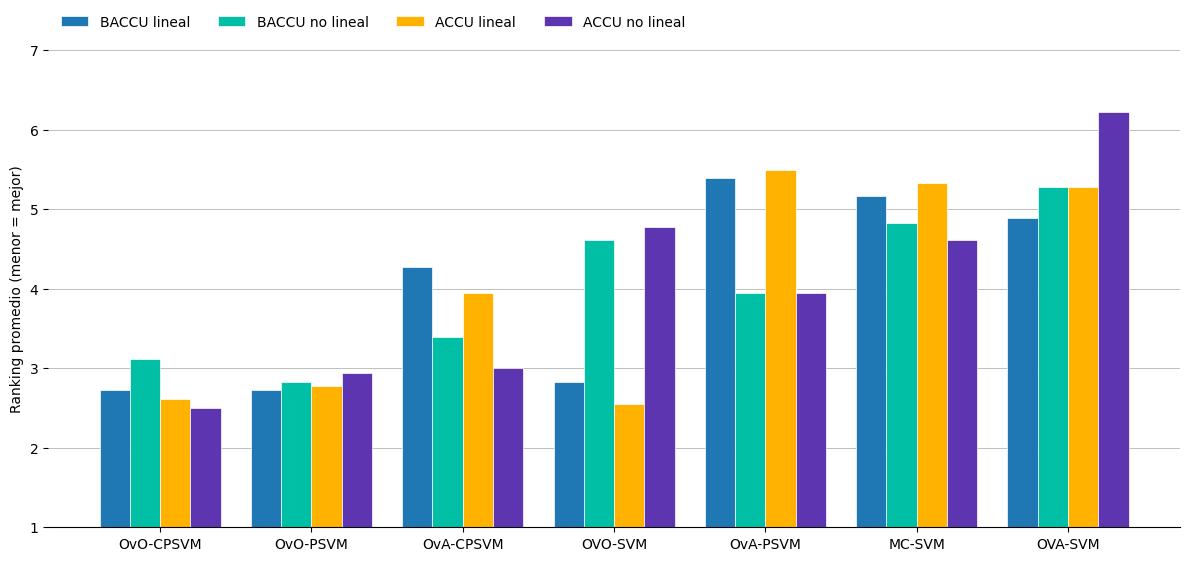

In [4]:
# Usar el estilo por defecto de matplotlib (fondo blanco)
plt.style.use('default')

# Crear la figura y asegurar el fondo blanco
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Configuración de las barras
x = np.arange(len(modelos))
ancho_barra = 0.2
# Desplazamientos para agrupar las 4 barras por cada modelo
desplazamiento = [-1.5, -0.5, 0.5, 1.5]

# Colores extraídos de tu imagen de referencia (se mantienen igual)
colores = {
    "BACCU lineal": "#1f77b4",     # Azul
    "BACCU no lineal": "#00bfa5",  # Verde esmeralda
    "ACCU lineal": "#ffb300",      # Amarillo/Naranja
    "ACCU no lineal": "#5e35b1"    # Morado
}

# Iterar y graficar cada categoría
for i, (categoria, color) in enumerate(colores.items()):
    # Extraer los rangos asegurando el orden de 'modelos' calculado en la Celda 2
    valores = [datos_plot[categoria].get(m, 0) for m in modelos]
    
    # Dibujar las barras (el borde ahora es blanco para separar ligeramente las barras si se tocan)
    ax.bar(x + desplazamiento[i] * ancho_barra, valores, ancho_barra, 
           label=categoria, color=color, edgecolor='white', linewidth=0.5)

# Personalización de los ejes (Texto en negro)
ax.set_ylabel('Ranking promedio (menor = mejor)', color='black', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(modelos, color='black', fontsize=10)

# Ajustar los límites del eje Y para que comience en 1
ax.set_ylim(1, 7)

# Configuración de la cuadrícula horizontal (Gris)
ax.yaxis.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True) # Enviar la cuadrícula detrás de las barras

# Configuración de los bordes y ticks para el tema claro
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('black')
ax.tick_params(axis='x', colors='black')
ax.tick_params(axis='y', colors='black')

# Configuración de la leyenda en la parte superior izquierda (Texto en negro)
ax.legend(loc='upper left', bbox_to_anchor=(0, 1.1), ncol=4, frameon=False, 
          fontsize=10, labelcolor='black')

# Ajustar el diseño y mostrar (se ajustó el margen inferior al quitar la nota)
plt.tight_layout(rect=[0, 0, 1, 0.95]) 
plt.show()